In [3]:
import torch
import torch.nn as nn

# Tensors
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(x.shape)

# Autograd
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2 + 3 * x
y.backward()
print(x.grad)

# Simple model
model = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
)
print(model)

torch.Size([2, 2])
tensor(7.)
Sequential(
  (0): Linear(in_features=10, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=2, bias=True)
)


In [4]:
model = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 2))

# Check — weights already tracked
print(model[0].weight.requires_grad)  # True — automatic

True


In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = datasets.ImageFolder('data/chest_xray/train', transform=transform)
test_data = datasets.ImageFolder('data/chest_xray/test', transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Classes: {train_data.classes}")
print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")
print(f"Batches per epoch: {len(train_loader)}")

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")

Classes: ['NORMAL', 'PNEUMONIA']
Train size: 5216
Test size: 624
Batches per epoch: 163
Batch shape: torch.Size([32, 3, 224, 224])


In [6]:
import os
print(os.getcwd())

C:\Users\AKSHAY\medical-diagnosis-assistant


In [7]:
import os
print(os.path.exists('data/chest_xray/train'))
print(os.listdir('data/chest_xray'))

True
['chest_xray', 'test', 'train', 'val', '__MACOSX']


In [9]:
train_data = datasets.ImageFolder('data/chest_xray/train', transform=transform)
test_data = datasets.ImageFolder('data/chest_xray/test', transform=transform)

Matplotlib is building the font cache; this may take a moment.


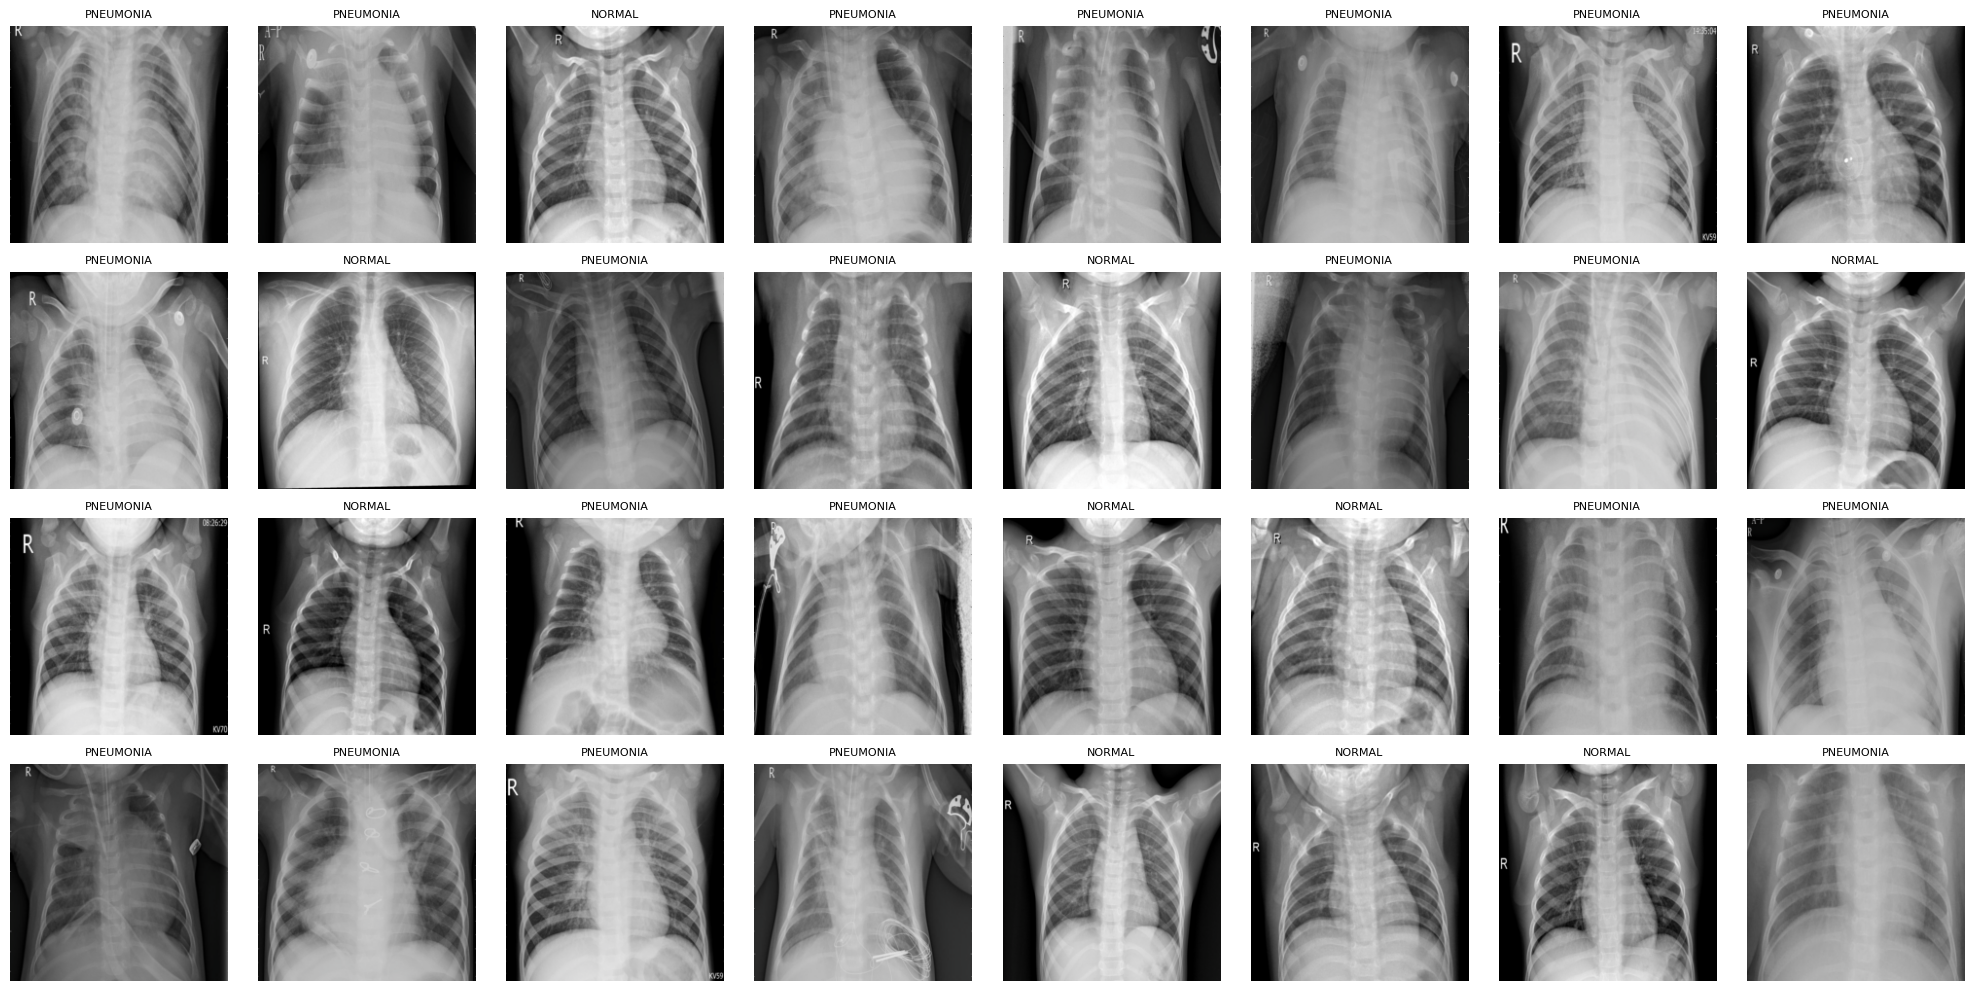

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(images, labels, classes):
    fig, axes = plt.subplots(4, 8, figsize=(20, 10))
    for i, ax in enumerate(axes.flat):
        img = images[i].numpy().transpose(1, 2, 0)
        # unnormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(classes[labels[i]], fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(images, labels, train_data.classes)